In [ ]:
pip install wrds

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.0/53.0 kB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 28.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.4/38.4 MB 18.0 MB/s eta 0:00:00
  Attempting uninstall: scipy
    Found existing installation: scipy 1.13.1
    Uninstalling scipy-1.13.1:
      Successfully uninstalled scipy-1.13.1
  Attempting uninstall: packaging
    Found existing installation: packaging 24.2
    Uninstalling packaging-24.2:
      Successfully uninstalled packaging-24.2


In [ ]:
import wrds
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.preprocessing import MinMaxScaler
from scipy.optimize import minimize
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.sequence import TimeseriesGenerator
from datetime import datetime


In [ ]:
###################
# Connect to WRDS #
###################
conn=wrds.Connection()

Enter your WRDS username [root]:abastin
Enter your password:··········
WRDS recommends setting up a .pgpass file.
Create .pgpass file now [y/n]?: n
You can create this file yourself at any time with the create_pgpass_file() function.
Loading library list...
Done


The following code block is the WRDS guide to optimizing the dataset, not internally created code. We utilized it as is due to complexity surrounding pulling from the CRSP dataset.

To access, use username: abastin, password cis1902*final

In [ ]:
## We neeed to change b.date I think** is there any way you can make it so we just start the connection with data from 2010
sp500 = conn.raw_sql("""
                        select a.*, b.date, b.ret
                        from crsp.msp500list as a,
                        crsp.msf as b
                        where a.permno=b.permno
                        and b.date >= a.start and b.date<= a.ending
                        and b.date>='01/01/2000'
                        order by date;
                        """, date_cols=['start', 'ending', 'date'])

mse = conn.raw_sql("""
                        select comnam, ncusip, namedt, nameendt,
                        permno, shrcd, exchcd, hsiccd, ticker
                        from crsp.msenames
                        """, date_cols=['namedt', 'nameendt'])

# if nameendt is missing then set to today date
mse['nameendt']=mse['nameendt'].fillna(pd.to_datetime('today'))

# Merge with SP500 data
sp500_full = pd.merge(sp500, mse, how = 'left', on = 'permno')

# Impose the date range restrictions
sp500_full = sp500_full.loc[(sp500_full.date>=sp500_full.namedt) \
                            & (sp500_full.date<=sp500_full.nameendt)]
ccm=conn.raw_sql("""
                  select gvkey, liid as iid, lpermno as permno, linktype, linkprim,
                  linkdt, linkenddt
                  from crsp.ccmxpf_linktable
                  where substr(linktype,1,1)='L'
                  and (linkprim ='C' or linkprim='P')
                  """, date_cols=['linkdt', 'linkenddt'])

# if linkenddt is missing then set to today date
ccm['linkenddt']=ccm['linkenddt'].fillna(pd.to_datetime('today'))

# Merge the CCM data with S&P500 data
# First just link by matching PERMNO
sp500ccm = pd.merge(sp500_full, ccm, how='left', on=['permno'])

# Then set link date bounds
sp500ccm = sp500ccm.loc[(sp500ccm['date']>=sp500ccm['linkdt'])\
                        &(sp500ccm['date']<=sp500ccm['linkenddt'])]

sp500ccm = sp500ccm.drop(columns=['namedt', 'nameendt', \
                                  'linktype', 'linkprim', 'linkdt', 'linkenddt'])
sp500ccm = sp500ccm[['date', 'permno', 'comnam', 'ncusip', 'shrcd', 'exchcd', 'hsiccd', 'ticker', \
                     'gvkey', 'iid', 'start', 'ending', 'ret']]

cnt = sp500ccm.groupby(['date'])['permno'].count().reset_index().rename(columns={'permno':'npermno'})

This is where our code begins:

In [ ]:
#Sort the dataset in order to only include stocks that are currently listed on the S&P and sort it again to put all companies with each other
# (by permno to avoid issues with companies relisting like Google and Alphabet)
curr = sp500ccm[sp500ccm['ending'] == '2023-12-29']
curr = sp500ccm.loc[(sp500ccm['start'] > '2010-01-01')]

curr = curr.sort_values(['permno', 'date'], ascending=[True, True])
curr


,date,permno,comnam,ncusip,shrcd,exchcd,hsiccd,ticker,gvkey,iid,start,ending,ret
81056,2010-04-30,10909,CERNER CORP,15678210,11,3,7373,CERN,012850,01,2010-04-30,2022-06-07,-0.001884
81778,2010-05-28,10909,CERNER CORP,15678210,11,3,7373,CERN,012850,01,2010-04-30,2022-06-07,-0.012504
82087,2010-06-30,10909,CERNER CORP,15678210,11,3,7373,CERN,012850,01,2010-04-30,2022-06-07,-0.093418
83002,2010-07-30,10909,CERNER CORP,15678210,11,3,7373,CERN,012850,01,2010-04-30,2022-06-07,0.020556
83202,2010-08-31,10909,CERNER CORP,15678210,11,3,7373,CERN,012850,01,2010-04-30,2022-06-07,-0.059393
...,...,...,...,...,...,...,...,...,...,...,...,...,...
179928,2023-08-31,93436,TESLA INC,88160R10,11,3,9999,TSLA,184996,01,2020-12-21,2023-12-29,-0.034962
180498,2023-09-29,93436,TESLA INC,88160R10,11,3,9999,TSLA,184996,01,2020-12-21,2023-12-29,-0.030456
181218,2023-10-31,93436,TESLA INC,88160R10,11,3,9999,TSLA,184996,01,2020-12-21,2023-12-29,-0.197346
181806,2023-11-30,93436,TESLA INC,88160R10,11,3,9999,TSLA,184996,01,2020-12-21,2023-12-29,0.195379


Start the Optimization process with the cleaned dataset:

In [ ]:
#collapse curr into date listed, mean, and ticker for simplicity
curr = curr.groupby(['date', 'ticker'], as_index=False)['ret'].mean()

#We utilize the Sharpe Ratio to classify portfolio efficiency. For that we need covariance, and average returns.
def calculate_portfolio_inputs(df):
    pivot = df.pivot(index='date', columns='ticker', values='ret')
    avgRet = pivot.mean()
    covMat = pivot.cov()
    return avgRet, covMat

avgRet, covMat = calculate_portfolio_inputs(curr)

#We filled the covariance matrix with 0, as it's impossible to remove all the rows with NA, as that deletes all rows from the matrix.
#By having the stocks covary with a rate of 0, it makes it highly unlikely that those two stocks are chosen together.

covMat = covMat.fillna(0)


In [ ]:
covMat

ticker,AAL,AAP,ABBV,ABMD,ABNB,ACE,ACGL,ACN,ADNT,ADS,...,WCG,WLTW,WPX,WRB,WST,WTW,XEC,XYL,ZBRA,ZTS
ticker,,,,,,,,,,,,,,,,,,,,,
AAL,0.014369,0.003506,0.001863,0.004590,0.009584,0.002753,-0.002283,0.003153,0.0,0.008242,...,0.003248,0.002426,0.000000,0.003653,0.001392,0.002657,0.003358,0.003767,0.008889,0.001810
AAP,0.003506,0.011388,0.002808,0.003322,0.000000,0.001838,0.006619,0.002520,0.0,0.008393,...,-0.000020,0.001018,0.000000,0.003814,0.002777,0.001844,0.002451,0.002287,0.007678,0.002762
ABBV,0.001863,0.002808,0.005408,0.003415,0.004368,0.001407,-0.000475,0.001697,0.0,0.003201,...,-0.000160,0.001453,0.001263,0.002315,0.001339,0.000158,0.000963,0.001654,0.003495,0.001450
ABMD,0.004590,0.003322,0.003415,0.020586,0.000000,0.000000,0.000000,0.005246,0.0,0.012606,...,0.006199,0.001145,0.000000,0.002061,0.007841,0.009689,0.002422,0.003865,0.007481,0.002676
ABNB,0.009584,0.000000,0.004368,0.000000,0.010290,0.000000,-0.007085,0.004299,0.0,0.000000,...,0.000000,0.000000,0.000000,-0.001700,0.008805,-0.005880,0.000000,0.001645,0.010081,0.008759
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
WTW,0.002657,0.001844,0.000158,0.009689,-0.005880,0.000000,0.001117,0.002125,0.0,0.000000,...,0.000000,0.000000,0.000000,0.001579,0.001246,0.004037,0.000000,0.003026,0.002631,0.000450
XEC,0.003358,0.002451,0.000963,0.002422,0.000000,0.000162,0.000000,0.002342,0.0,0.003871,...,0.004787,0.001543,0.000000,0.006137,0.000000,0.000000,0.010479,0.002640,0.013548,0.000311
XYL,0.003767,0.002287,0.001654,0.003865,0.001645,0.001074,-0.000596,0.002153,0.0,0.004437,...,0.001661,0.001517,0.001572,0.001983,0.002610,0.003026,0.002640,0.004853,0.005819,0.002046


In [ ]:
""" Finds the Sharpe Ratio of the portfolio, an objective measure used to
evaluate the portfolio on efficiency in both return and volatility.

It finds return through just finding the weighted mean of the portfolio.

It finds volatility of a portfolio based on assigned weights and the covariance
matrix. Takes the dot product of the covariance matrix with the weights, then
again with the transpose of the weights matrix. This gives the variance of the
portfolio returns. We then take the square root (with a clip to solve for
potential negative values) to get standard deviation. This is based on the
portfolio variance matrix for calculating variance.

It then plugs it into the formula for the sharpe ratio. It returns the negative
version, as we want to maximize the sharpe ratio but scipy.optimize only has a
minimize function"""

def sharpe_ratio(weights, avgRet, covMat, rf):
    pReturn = np.sum(weights * avgRet)
    try:
      pStdev = np.sqrt(np.dot(weights.T, np.dot(covMat, weights)))
    except:
      sr = 0
    sr = (pReturn - rf) / pStdev
    return -sr

In [ ]:
num_assets = len(avgRet)

# constrains to make sure the stock weights sum to one, the max weight
# is no greater than 10% of the portfolio, weights are not negative
# and cardinality.
constraints = [
    {'type': 'eq', 'fun': lambda x: np.sum(x) - 1},
    {'type': 'ineq', 'fun': lambda x: x},
    {'type': 'ineq', 'fun': lambda x: 0.1 - x},
]
bounds = tuple((0, 1) for _ in range(num_assets))

In [ ]:
def optimize_portfolio(avgRet, covMat, risk_free_rate):
    num_assets = len(avgRet)
    initial_weights = np.array(num_assets * [1. / num_assets])

    args = (avgRet, covMat, risk_free_rate)
    result = minimize(sharpe_ratio, initial_weights, args=args,
                      method='SLSQP', bounds=bounds, constraints=constraints)
    return result.x

risk_free_rate = .02
optimal_weights = optimize_portfolio(avgRet, covMat, risk_free_rate)

<ipython-input-8-2e7c480203f5>:20: RuntimeWarning: invalid value encountered in sqrt
  pStdev = np.sqrt(np.dot(weights.T, np.dot(covMat, weights)))


In [ ]:
def portfolio_performance(weights, avgRet, covMat):
    portfolio_return = np.sum(weights * avgRet)
    portfolio_volatility = np.sqrt(np.dot(weights.T, np.dot(covMat, weights)))
    sharpe_ratio = (portfolio_return - risk_free_rate) / portfolio_volatility
    return portfolio_return, portfolio_volatility, sharpe_ratio

return_X, volatility, sharpe = portfolio_performance(optimal_weights, avgRet, covMat)

print("Optimal Portfolio Weights:")
for asset, weight in zip(avgRet.index, optimal_weights):
    if weight > 0.01:
        print(f"{asset}: {weight:.4f}")

print(f"\nExpected Annual Return: {return_X*252:.4f}")
print(f"Expected Annual Volatility: {volatility*np.sqrt(252):.4f}")
print(f"Sharpe Ratio: {sharpe/np.sqrt(252):.4f}")

Optimal Portfolio Weights:
ACGL: 0.0554
AXON: 0.0100
BLDR: 0.0968
BXLT: 0.0614
CBE: 0.0106
CERN: 0.0174
CVC: 0.0343
EG: 0.0538
EQT: 0.0213
FL: 0.0194
ILMN: 0.0112
JBL: 0.0889
JOYG: 0.0121
KORS: 0.0310
LULU: 0.0320
MMI: 0.0252
NAVI: 0.0310
PAYC: 0.0570
Q: 0.0702
UBER: 0.0889
VLTO: 0.0913
WTW: 0.0360

Expected Annual Return: 16.3220
Expected Annual Volatility: 0.0202
Sharpe Ratio: 2.2123


Part 2: Focusing on taking in a collection of stocks and their weights in the portfolio and predicting their future price based on past price data.

Input your portfolio tickers and weights:
Enter ticker: LULU
Enter weight for LULU (remaining: 1.00): 0.3
Enter ticker: META
Enter weight for META (remaining: 0.70): 0.2
Enter ticker: WBA
Enter weight for WBA (remaining: 0.50): 0.5


/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 52ms/step - loss: 0.0658
Epoch 2/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0581 
Epoch 3/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 0.0455
Epoch 4/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.0328
Epoch 5/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 0.0275
Epoch 6/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 0.0169
Epoch 7/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0117
Epoch 8/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0071 
Epoch 9/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.0054
Epoch 10/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 0.0052
Epoch 11/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0059 
Epoch 12/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 0.0051
Epoch 13/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 0.0047
Epoch 14/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 0.0037
Epoch 15/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.0036
Epoch 16/20
3/3 ━━━━━━━━━━━━━━━

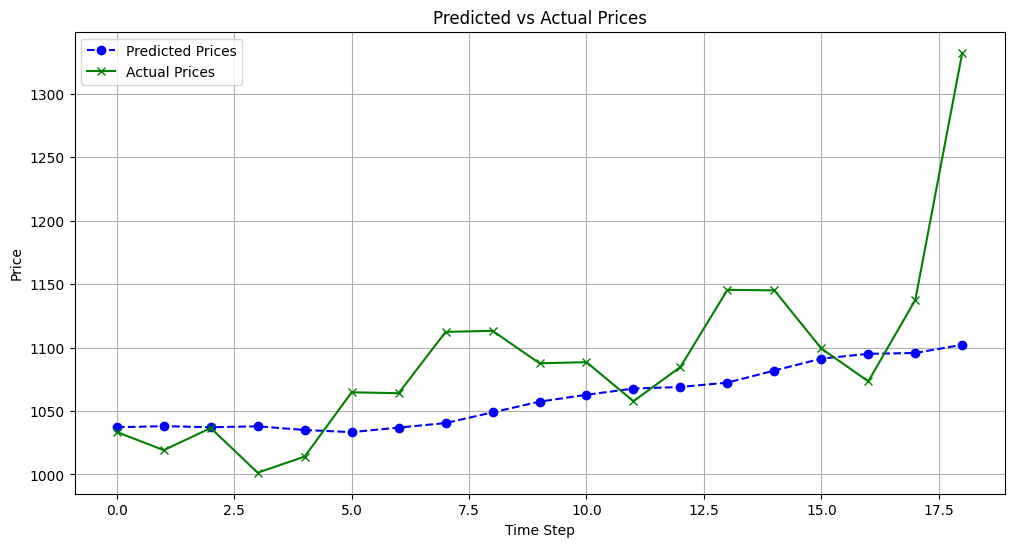

In [ ]:
"""Part 2: Focusing on taking in a collection of stocks and their weights in the portfolio and predicting their future price based on past price data."""
class PricePredictor:
    def __init__(self, data, lookback=15):
        """
        Initialize the predictor with historical data.

        Parameters:
            data (pd.DataFrame): Historical stock prices with 'date', 'ticker', and 'price' columns.
            lookback (int): Number of past days to use for predictions.
        """
        self.data = data
        self.lookback = lookback
        self.scaler = MinMaxScaler()
        self.model = None

    def _prepare_data(self, tickers, weights):
        """Prepare weighted portfolio data for training and testing."""
        weighted_prices = pd.DataFrame()

        for ticker, weight in zip(tickers, weights):
            stock_data = self.data[self.data['ticker'] == ticker].copy()
            if stock_data.empty:
                raise ValueError(f"No data found for ticker {ticker}. Ensure it exists in the dataset.")
            stock_data['price'] = self.scaler.fit_transform(stock_data[['price']]) * weight

            if weighted_prices.empty:
                weighted_prices = stock_data[['date', 'price']].set_index('date')
            else:
                weighted_prices = weighted_prices.add(stock_data[['date', 'price']].set_index('date'), fill_value=0)

        if weighted_prices.isna().sum().sum() > 0:
            raise ValueError("Combined weighted prices contain missing values. Check the data for gaps.")

        weighted_prices = weighted_prices.reset_index()
        series = weighted_prices['price'].values

        X, y = [], []
        for i in range(len(series) - self.lookback):
            X.append(series[i:i + self.lookback])
            y.append(series[i + self.lookback])

        if len(X) == 0 or len(y) == 0:
            raise ValueError(
                f"Not Enough data"
            )

        X = np.array(X, dtype=np.float32)
        y = np.array(y, dtype=np.float32)

        X = np.nan_to_num(X, nan=0.0,
                              posinf=np.finfo(np.float32).max,
                              neginf=np.finfo(np.float32).min)
        y = np.nan_to_num(y, nan=0.0,
                          posinf=np.finfo(np.float32).max,
                          neginf=np.finfo(np.float32).min)

        # Split into training and testing (80/20 split)
        train_size = int(len(X) * 0.8)
        train_X, test_X = X[:train_size], X[train_size:]
        train_y, test_y = y[:train_size], y[train_size:]

        # Check shapes
        if train_X.size == 0 or test_X.size == 0:
            raise ValueError("Training or testing data is empty.")

        train_X = train_X.reshape(train_X.shape[0], train_X.shape[1], 1)
        test_X = test_X.reshape(test_X.shape[0], test_X.shape[1], 1)

        return train_X, train_y, test_X, test_y

    def build_model(self):
        """Build and compile the LSTM model, using some suggested parameters."""
        self.model = Sequential([
            LSTM(50, activation='relu', input_shape=(self.lookback, 1)),
            Dense(1)
        ])
        self.model.compile(optimizer='adam', loss='mse')

    def train(self, train_X, train_y, epochs=50, batch_size=32):
        """Train the LSTM model."""
        if self.model is None:
            self.build_model()

        self.model.fit(train_X, train_y, epochs=epochs, batch_size=batch_size, verbose=1)

    def predict(self, test_X, future_steps=90):
        """Predict future prices for the next 'future_steps' days."""
        predictions = []
        last_sequence = test_X[-1]

        for _ in range(future_steps):
            pred = self.model.predict(last_sequence.reshape(1, self.lookback, 1), verbose=0)[0][0]
            predictions.append(pred)
            last_sequence = np.append(last_sequence[1:], pred)

        return self.scaler.inverse_transform(np.array(predictions).reshape(-1, 1)).flatten()

    def evaluate(self, test_X, test_y):
        """Evaluate the model on the test dataset."""
        predictions = self.model.predict(test_X, verbose=0).flatten()
        predictions = self.scaler.inverse_transform(predictions.reshape(-1, 1)).flatten()
        actuals = self.scaler.inverse_transform(test_y.reshape(-1, 1)).flatten()

        mse = mean_squared_error(actuals, predictions)
        mae = mean_absolute_error(actuals, predictions)

        return mse, mae, predictions, actuals

# Example Usage
if __name__ == "__main__":
    sp500ccm['price'] = sp500ccm['ret'].cumsum()
    data = sp500ccm[['date', 'ticker', 'price']]

    tickers, weights = [], []
    total_weight = 0

    print("Input your portfolio tickers and weights:")
    while total_weight < 1.0:
        ticker = input("Enter ticker: ")
        weight = float(input(f"Enter weight for {ticker} (remaining: {1.0 - total_weight:.2f}): "))

        if total_weight + weight > 1.0:
            print("Total weight cannot exceed 1.0. Try again.")
            continue

        tickers.append(ticker)
        weights.append(weight)
        total_weight += weight

    if abs(total_weight - 1.0) > 0.001:
        print("Total weight must equal 1.0. Adjust your inputs.")
        exit()

    predictor = PricePredictor(data)

    try:
        train_X, train_y, test_X, test_y = predictor._prepare_data(tickers, weights)

        predictor.train(train_X, train_y, epochs=20, batch_size=32)

        mse, mae, predicted_prices, actual_prices = predictor.evaluate(test_X, test_y)

        print(f"Model Evaluation - MSE: {mse:.4f}, MAE: {mae:.4f}")

        print("Predicted vs Actual Prices:")
        for pred, actual in zip(predicted_prices, actual_prices):
            print(f"Predicted: {pred:.2f}, Actual: {actual:.2f}")

    except ValueError as e:
        print(f"Error: {e}")

# Visualization of the data
plt.figure(figsize=(12, 6))
plt.plot(predicted_prices, label='Predicted Prices', color='blue', marker='o', linestyle='dashed')
plt.plot(actual_prices, label='Actual Prices', color='green', marker='x', linestyle='solid')
plt.title('Predicted vs Actual Prices')
plt.xlabel('Time Step')
plt.ylabel('Price')
plt.legend()
plt.grid()
plt.show()

In [ ]:
#A function to predict returns per monnth of our stock portfolio
class ReturnsPredictor:
    def __init__(self, data):
        """
        Initialize the ReturnsPredictor with historical stock data.

        Parameters:
        data (pd.DataFrame): The dataset containing stock data with 'date', 'ticker', and 'ret' columns.
        """
        self.data = data
        self.model = None

    def _prepare_data(self, tickers, weights):
        """
        Prepare the data for the portfolio based on tickers and weights.

        Parameters:
        tickers (list): List of stock tickers in the portfolio.
        weights (list): List of corresponding weights for each ticker.

        Returns:
        X_train, X_test, y_train, y_test: Training and testing datasets for the model.
        """
        # Filter data for selected tickers and calculate weighted returns
        data_filtered = self.data[self.data['ticker'].isin(tickers)].copy()

        # Ensure 'ret' column is clean and numeric
        data_filtered['ret'] = data_filtered['ret'].replace([np.inf, -np.inf], np.nan).dropna()

        # Calculate weighted returns with explicit float type
        data_filtered['weighted_return'] = 0.0
        for ticker, weight in zip(tickers, weights):
            data_filtered.loc[data_filtered['ticker'] == ticker, 'weighted_return'] = (
                weight * data_filtered.loc[data_filtered['ticker'] == ticker, 'ret'].astype(float)
            )

        # Group by date to calculate portfolio returns
        portfolio_data = data_filtered.groupby('date').agg({'weighted_return': 'sum'}).reset_index()

        # Add lagged features for historical returns
        portfolio_data['lagged_return_1'] = portfolio_data['weighted_return'].shift(1).fillna(0)
        portfolio_data['lagged_return_5'] = portfolio_data['weighted_return'].rolling(window=5).mean().fillna(0)

        # Filter data up to the end of 2022
        portfolio_data = portfolio_data[portfolio_data['date'] <= datetime(2022, 12, 31)]

        # Prepare features (X) and target (y)
        portfolio_data['date_ordinal'] = portfolio_data['date'].map(datetime.toordinal)
        X = portfolio_data[['lagged_return_1', 'lagged_return_5']].values
        y = portfolio_data['weighted_return'].values

        # Split into training and testing datasets
        split_index = int(len(X) * 0.8)
        X_train, X_test = X[:split_index], X[split_index:]
        y_train, y_test = y[:split_index], y[split_index:]

        return X_train, X_test, y_train, y_test

    def train_model(self, X_train, y_train, lookback=5):
        """
        Train an LSTM model to predict returns.

        Parameters:
        X_train (np.array): Training features.
        y_train (np.array): Training target.
        lookback (int): Number of past steps to consider for prediction.
        """
        # Reshape data for LSTM
        generator = TimeseriesGenerator(X_train, y_train, length=lookback, batch_size=32)

        self.model = Sequential([
            LSTM(50, activation='relu', input_shape=(lookback, X_train.shape[1])),
            Dense(1)
        ])
        self.model.compile(optimizer='adam', loss='mse')
        self.model.fit(generator, epochs=20, verbose=1)

    def evaluate_model(self, X_test, y_test, lookback=5):
        """
        Evaluate the model using the test dataset.

        Parameters:
        X_test (np.array): Testing features.
        y_test (np.array): Testing target.

        Returns:
        mse (float): Mean Squared Error of the model.
        mae (float): Mean Absolute Error of the model.
        predictions (np.array): Model predictions.
        actuals (np.array): Actual returns from the test set.
        """
        # Reshape data for LSTM evaluation
        generator = TimeseriesGenerator(X_test, y_test, length=lookback, batch_size=1)

        predictions = self.model.predict(generator).flatten()
        mse = mean_squared_error(y_test[lookback:], predictions)
        mae = mean_absolute_error(y_test[lookback:], predictions)
        return mse, mae, predictions, y_test[lookback:]

    def predict_2023(self, lookback=5):
        """
        Predict returns for the year 2023 and compare to actual data.

        Returns:
        predicted_returns (np.array): Predicted returns for 2023.
        actual_returns (np.array): Actual returns for 2023.
        """
        data_2023 = self.data[self.data['date'].dt.year == 2023].copy()
        data_2023['lagged_return_1'] = data_2023['ret'].shift(1).fillna(0)
        data_2023['lagged_return_5'] = data_2023['ret'].rolling(window=5).mean().fillna(0)

        X_2023 = data_2023[['lagged_return_1', 'lagged_return_5']].values
        y_2023 = data_2023['ret'].values

        generator = TimeseriesGenerator(X_2023, y_2023, length=lookback, batch_size=1)
        predicted_returns = self.model.predict(generator).flatten()
        actual_returns = y_2023[lookback:]
        return predicted_returns, actual_returns

# Example Usage
if __name__ == "__main__":
    # Assume sp500ccm is the dataset with columns: 'date', 'ticker', 'ret'
    sp500ccm['date'] = pd.to_datetime(sp500ccm['date'])  # Ensure date is in datetime format

    # Initialize predictor and prepare data
    predictor = ReturnsPredictor(sp500ccm)
    X_train, X_test, y_train, y_test = predictor._prepare_data(tickers, weights)

    # Train model
    predictor.train_model(X_train, y_train)

    # Evaluate model
    mse, mae, predictions, actuals = predictor.evaluate_model(X_test, y_test)
    print(f"Model Evaluation - MSE: {mse:.4f}, MAE: {mae:.4f}")

    # Predict returns for 2023
    predicted_2023, actual_2023 = predictor.predict_2023()

    # Plot predicted vs actual returns for 2023


    print(f"The predicted average return per month is {np.mean(predicted_2023)}")
    print(f"The predicted standard deviation of our returns per month is {np.sqrt(np.var(predicted_2023))}")

Epoch 1/20


/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0020
Epoch 2/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0021 
Epoch 3/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0016 
Epoch 4/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0013     


/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 5/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0020 
Epoch 6/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0020
Epoch 7/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0020 
Epoch 8/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0013     
Epoch 9/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0016
Epoch 10/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0019
Epoch 11/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0018 
Epoch 12/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0013    
Epoch 13/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0018 
Epoch 14/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0016 
Epoch 15/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0012     
Epoch 16/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0012     
Epoch 17/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0012     
Epoch 18/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0012     
Epoch 19/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0016 
Epoch 

/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


5995/5995 ━━━━━━━━━━━━━━━━━━━━ 22s 4ms/step
The predicted average return per month is 0.009181154891848564
The predicted standard deviation of our returns per month is 0.007910744287073612


In [ ]:
''''We finally score the provided portfolio against the optimized portfolio (for
the given timeframe). We utilize logic to grade the provided portfolio on return,
risk, Diversification, and Sharpe Ratio on a 100 point scale. The maximum a
portfolio can receive in each section is 25, and the minimum is typically 20 to
allow some padding for scores. Thus, the true range is 80-100. The scoring is
based on a version of the portfolio calculated to only include stocks within a
more recent year range and with enough data to '''

#find the cumulative mean and standard deviation of return, meaning we divide
#prices

cumRet_mean = np.mean(predicted_2023)
cumRet_stdev = np.sqrt(np.var(predicted_2023))

#find the difference to be utilized in the score_ret and score_vol
score_ret = (cumRet_mean - 4.6737404)
score_vol = (cumRet_stdev - 0.8063589)

#calculate the score based on return
if (score_ret >= 0):
  score_ret = 25
else:
  score_ret = np.abs(4.6737404-np.abs(score_ret)*100000000)
  score_ret = np.minimum(score_ret, 4.99999)
  score_ret = 20 + score_ret

#calculate the score based on volatility
if (score_vol >= 0):
  score_vol = 25
else:
  score_vol = np.abs(0.8063589-np.abs(score_vol)*100000000)
  score_vol = np.minimum(score_vol, 4.99999)
  score_vol = 20 + score_vol

#calculate the score based on diversification
score_div = 0
for w in weights:
  score_div += np.abs((w - 0.1))/w

if (len(weights) >= 10):
  score_div = 25
else:
  score_div = score_div*len(weights)/100*5
  score_div = np.minimum(score_div, 4.99999)
  score_div = 20 + score_div

#calculates the score based on the sharpe ratio
sr = (cumRet_mean - risk_free_rate) - cumRet_stdev

if sr > 6.5:
  score_sr = 5
elif sr < 0:
  score_sr = 0
else:
  score_sr = (sr-2.5)*3
  score_sr = np.minimum(4.99999, score_sr)

score_sr = score_sr + 20
print(f"Total score: {score_sr + score_div + score_vol + score_ret:.4f}")

Total score: 90.2950
